In [1]:
from spicelib import AscEditor
from spicelib.simulators.ltspice_simulator import LTspice

# 1. Configurar librerías (rutas en tu Mac)
ruta_sym = "/Users/emolina/Library/Application Support/LTspice/lib/sym"
ruta_sub = "/Users/emolina/Library/Application Support/LTspice/lib/sub"
ruta_cmp = "/Users/emolina/Library/Application Support/LTspice/lib/cmp"
AscEditor.set_custom_library_paths(ruta_sym, ruta_sub, ruta_cmp)

# 2. Cargar tu archivo
editor = AscEditor("preamp.asc")

# (Aquí harías tus cambios si los necesitas)
# editor.set_component_value('R1', '10k')

# 3. Guardar el esquemático modificado (¡Usando la función correcta!)
# Nota que le pasamos la extensión .asc
editor.save_netlist("preamp_modificado.asc") 

# 4. Usar la clase del simulador para invocar a LTspice y que genere el .net
# Esto leerá "preamp_modificado.asc" y creará "preamp_modificado.net"
LTspice.create_netlist("preamp_modificado.asc")

print("Esquemático y Netlist generados con éxito.")
#NotImplementedError: MacOS native LTspice does not have netlist generation capabilities. Use LTspice under wine.

NotImplementedError: MacOS native LTspice does not have netlist generation capabilities. Use LTspice under wine.

In [2]:
from spicelib import SpiceEditor

# 1. Cargamos tu netlist
netlist = SpiceEditor("preamp.net")

# --- CAMBIO 1: El "Tone Stack" (Parámetros) ---
# Tienes todo plano (0.5) y el volumen al máximo (1).
# Vamos a darle un tono más "gordo" para rock: subimos graves, bajamos un poco agudos, 
# mantenemos el drive alto, pero bajamos el volumen de salida a 0.8 para evitar 
# que el archivo .wav final clipee digitalmente al exportarlo.
netlist.set_parameters(bass=0.75, treble=0.4, vol=0.8, drive=1.0)

# --- CAMBIO 2: Modificación de Componentes (Filtro de entrada) ---
# C1 (22nF) forma un filtro paso alto en la entrada. Si queremos que pasen 
# más frecuencias graves de la guitarra antes de distorsionar, lo subimos a 47nF.
netlist.set_component_value('C1', '47n')

# Podríamos cambiar el transistor JFET de entrada por otro muy clásico en pedales:
netlist.set_element_model('J1', 'J310')

# --- CAMBIO 3: Tiempo de simulación (.TRAN) ---
# OJO AQUÍ: Tienes ".tran 1u 1.01 1". Esto significa que la simulación empieza a guardar 
# datos en el segundo 1 y termina en el 1.01. ¡Son solo 10 milisegundos de audio!
# No vas a poder escuchar casi nada en el "output.wav". 
# Vamos a borrar esa instrucción y a poner una para simular 2 segundos enteros.
netlist.remove_instruction(".tran 1u 1.01 1")
netlist.add_instructions(".tran 5") # Pasos de 10us hasta 2 segundos

# 4. Guardamos la nueva versión lista para rugir
netlist.save_netlist("preamp_fat_tone.net")
print("Netlist modificado y guardado como preamp_fat_tone.net")

Instruction ".tran 1u 1.01 1
" not found.


Netlist modificado y guardado como preamp_fat_tone.net


In [4]:
from spicelib import SimRunner
from spicelib.simulators.ltspice_simulator import LTspice
import time

# 1. Definimos nuestro simulador nativo para Mac
class MacLTspice(LTspice):
    # Le pasamos la ruta exacta al binario dentro del .app (como una lista)
    spice_exe = ['/Applications/LTspice.app/Contents/MacOS/LTspice']

# 2. Configuramos el SimRunner usando nuestra nueva clase MacLTspice
runner = SimRunner(simulator=MacLTspice, output_folder='./resultados_audio')

print("🎸 Conectando la guitarra virtual y encendiendo los amplificadores...")
start_time = time.time()

# 3. Lanzamos la simulación del netlist modificado
runner.run("preamp_fat_tone.net")

# 4. Recogemos los resultados
for raw, log in runner:
    print("\n✅ ¡Simulación completada con éxito!")
    print(f"📄 Archivo de datos RAW: {raw}")
    print(f"📄 Archivo de registro LOG: {log}")

end_time = time.time()
print(f"⏱️ Tiempo total de simulación: {round(end_time - start_time, 2)} segundos.")
print(f"📊 Simulaciones exitosas: {runner.okSim} / {runner.runno}")

🎸 Conectando la guitarra virtual y encendiendo los amplificadores...

✅ ¡Simulación completada con éxito!
📄 Archivo de datos RAW: resultados_audio/preamp_fat_tone_1.raw
📄 Archivo de registro LOG: resultados_audio/preamp_fat_tone_1.log
⏱️ Tiempo total de simulación: 5.73 segundos.
📊 Simulaciones exitosas: 1 / 1


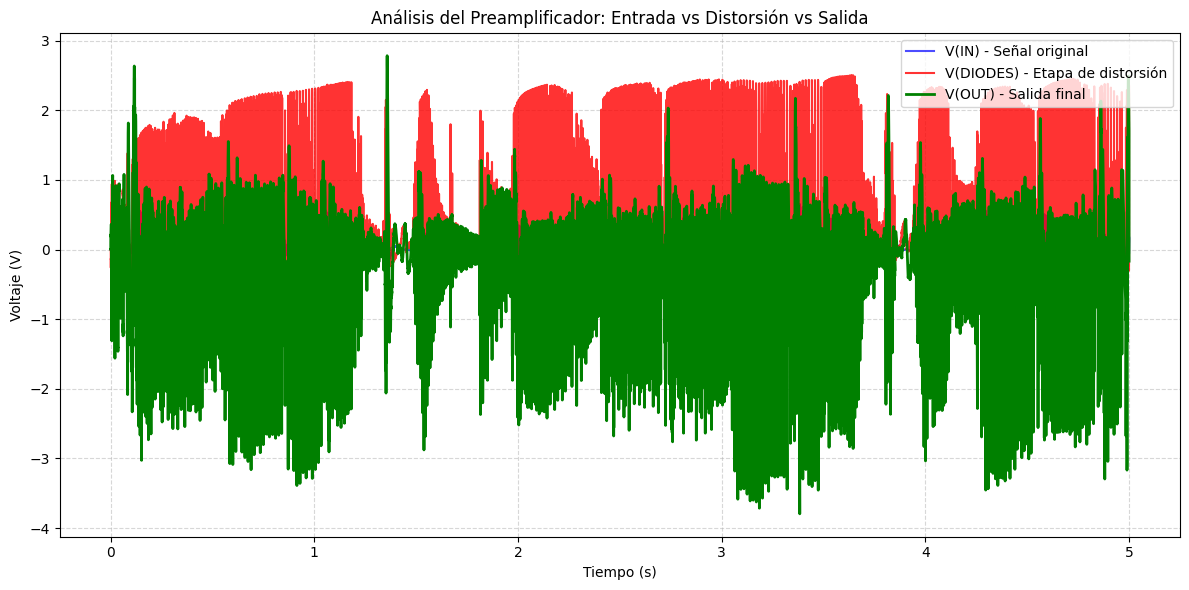

In [5]:
from spicelib import RawRead
import matplotlib.pyplot as plt

# 1. Cargamos el archivo de resultados (asegúrate de poner el nombre correcto que se haya generado)
# Si usaste SimRunner con output_folder, la ruta será algo como './resultados_audio/preamp_fat_tone_1.raw'
archivo_raw = "resultados_audio/preamp_fat_tone_1.raw" 
raw = RawRead(archivo_raw)

# 2. Extraemos el eje de tiempo (eje X)
# LTspice suele llamar a la variable de tiempo 'time'
tiempo = raw.get_trace('time').get_wave()

# 3. Extraemos las señales de voltaje que nos interesan (eje Y)
# Nota: LTspice normalmente guarda los nombres de los nodos en minúsculas, 
# pero RawRead suele ser flexible. Si te da error, prueba con 'V(in)', 'V(out)', etc.
v_in = raw.get_trace('V(in)').get_wave()
v_out = raw.get_trace('V(out)').get_wave()
v_diodes = raw.get_trace('V(diodes)').get_wave()

# 4. Configuramos el gráfico con matplotlib
plt.figure(figsize=(12, 6))

# Dibujamos cada señal con un color y etiqueta
plt.plot(tiempo, v_in, label='V(IN) - Señal original', color='blue', alpha=0.7)
plt.plot(tiempo, v_diodes, label='V(DIODES) - Etapa de distorsión', color='red', alpha=0.8)
plt.plot(tiempo, v_out, label='V(OUT) - Salida final', color='green', linewidth=2)

# 5. Damos formato al gráfico para que se vea profesional
plt.title("Análisis del Preamplificador: Entrada vs Distorsión vs Salida")
plt.xlabel("Tiempo (s)")
plt.ylabel("Voltaje (V)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

# Opcional: Si simulaste 5 segundos enteros, el gráfico puede verse muy "apretado".
# Puedes hacer zoom a un fragmento interesante (por ejemplo, entre el segundo 1.0 y 1.05)
# plt.xlim(1.0, 1.05)

# Mostramos la gráfica en pantalla
plt.tight_layout()
plt.show()

In [149]:
import os
os.system("cp preamp.net preamp-backup.net")

0

Preparando el netlist...
Lanzando simulaciones AC matriciales (25 combinaciones). Espere por favor...

✅ ¡Simulación terminada!
📄 RAW: resultados_ac/preamp_ac_sweep_2d_1.raw
📄 LOG: resultados_ac/preamp_ac_sweep_2d_1.log

--- 🔍 Resumen del Archivo LOG ---
  -> Warning: Multiple definitions of model "2scr375p" Type: BJT
  -> Warning: Multiple definitions of model "bc857b" Type: BJT
  -> Warning: Multiple definitions of model "bc847c" Type: BJT
  -> Warning: Multiple definitions of model "bc847b" Type: BJT
  -> Total elapsed time: 0.198 seconds.
----------------------------------

📊 Extrayendo datos y generando gráfico...


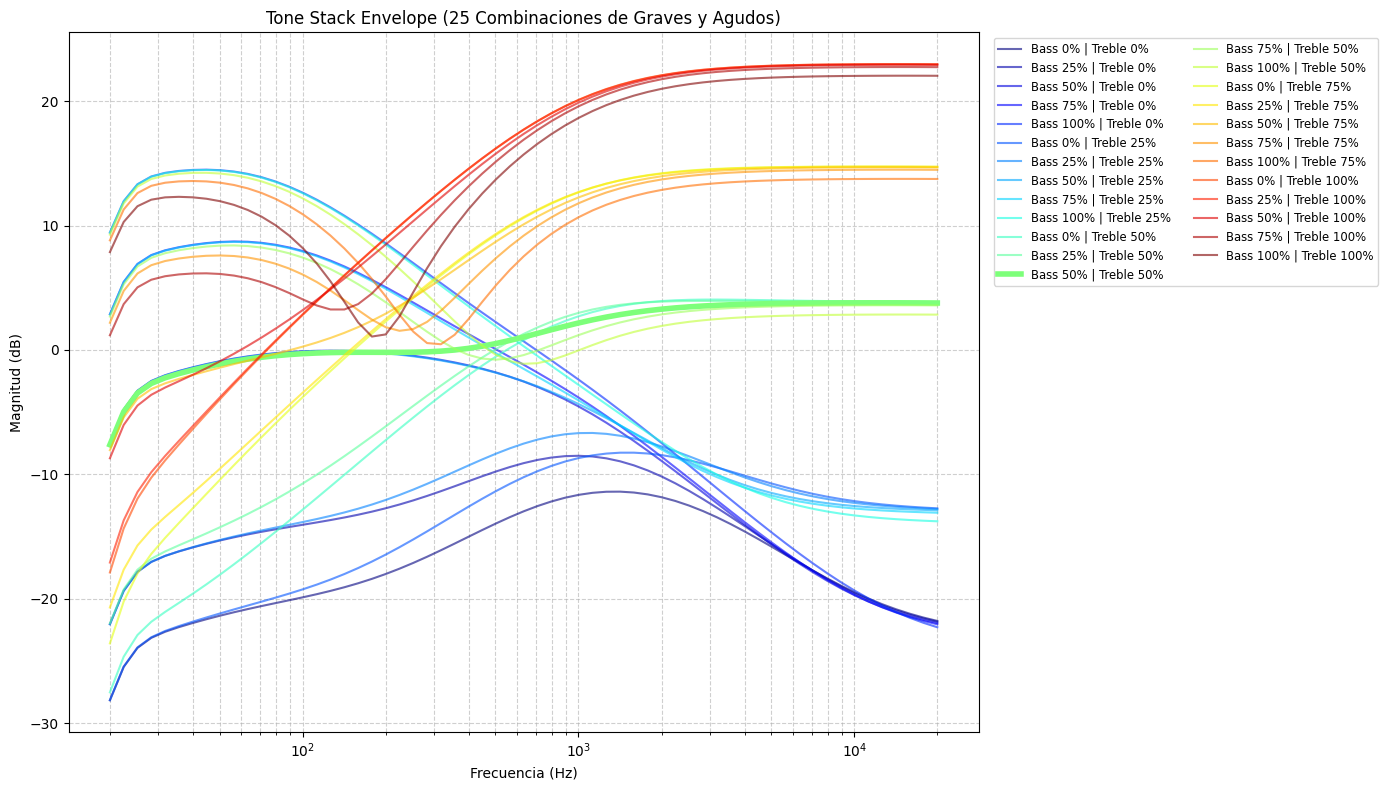

In [15]:
from spicelib import SpiceEditor, SimRunner, RawRead
from spicelib.simulators.ltspice_simulator import LTspice
import matplotlib.pyplot as plt
import numpy as np
import shutil
import os

# Vaciar la carpeta de resultados viejos antes de simular
results_dir = './resultados_ac'
if os.path.exists(results_dir):
    shutil.rmtree(results_dir) # Borra la carpeta y todo su contenido
os.makedirs(results_dir)       # La vuelve a crear vacía y limpia

# Definir la ruta del ejecutable de LTspice en macOS
class MacLTspice(LTspice):
    spice_exe = ['/Applications/LTspice.app/Contents/MacOS/LTspice']

print("Preparando el netlist...")
netlist = SpiceEditor("preamp-backup.net")

# 1) Eliminar componentes e instrucciones problemáticas de audio/transitorios
netlist.remove_component('V1')
netlist.remove_component('B1')
netlist.remove_component('B2')
try:
    netlist.remove_instruction('.wave "output.wav" 16 22.05k V(B1)')
except Exception:
    pass

# 2) LIMPIEZA MÁGICA: Eliminar cualquier línea en blanco antes de añadir nada
netlist.netlist = [x for x in netlist.netlist if x.strip()]

# 3) Añadir las nuevas instrucciones AC sobre un terreno limpio
netlist.add_instruction("V_AC IN 0 AC 1")
netlist.add_instruction(".ac dec 20 20 20k")

# Segunda limpieza de seguridad por si el '.ac' borró un '.tran' y dejó un hueco
netlist.netlist = [x for x in netlist.netlist if x.strip()] 

# Añadir los barridos de parámetros
netlist.add_instruction(".step param bass list 0 0.25 0.5 0.75 1")
netlist.add_instruction(".step param treble list 0 0.25 0.5 0.75 1")

# 4) Congelar los demás potenciómetros
netlist.set_parameters(vol=1.0, drive=0.5)

# Guardar y simular
netlist.save_netlist("preamp_ac_sweep_2d.net")
print("Lanzando simulaciones AC matriciales (25 combinaciones). Espere por favor...")

runner = SimRunner(simulator=MacLTspice, output_folder='./resultados_ac')
runner.run("preamp_ac_sweep_2d.net")

# El bucle 'for' actuará como bloqueante natural hasta que LTspice termine
for raw_path, log_path in runner:
    print(f"\n✅ ¡Simulación terminada!")
    print(f"📄 RAW: {raw_path}")
    print(f"📄 LOG: {log_path}")

    # --- EJEMPLO: RECUPERAR INFORMACIÓN DEL LOG ---
    # Leemos el archivo .log como un archivo de texto normal para buscar métricas o errores
    if os.path.exists(log_path):
        print("\n--- 🔍 Resumen del Archivo LOG ---")
        with open(log_path, 'r', encoding='utf-16-le', errors='ignore') as log_file:
            for linea in log_file:
                # Buscamos palabras clave de interés en cada línea
                if "Warning" in linea or "Fatal Error" in linea or "Total elapsed time" in linea:
                    print(f"  -> {linea.strip()}")
        print("----------------------------------\n")

    # --- LECTURA DE DATOS RAW Y PLOTEO ---
    if not os.path.exists(raw_path):
        print(f"❌ Error: El archivo {raw_path} no se generó correctamente.")
        continue

    print("📊 Extrayendo datos y generando gráfico...")
    raw = RawRead(raw_path)
    pasos_indices = raw.get_steps() 
    
    colores = plt.cm.jet(np.linspace(0, 1, len(pasos_indices)))
    plt.figure(figsize=(14, 8))
    
    for i in pasos_indices:
        # EXTRACCIÓN MANUAL DE FRECUENCIA PARA ESQUIVAR EL BUG DE get_axis()
        try:
            freq_complex = raw.get_trace('frequency').get_wave(i)
        except KeyError:
            freq_complex = raw.get_trace('freq').get_wave(i)
            
        freq = np.real(freq_complex)
        
        # Petición del nodo de salida
        try:
            v_out_complex = raw.get_trace('V(OUT)').get_wave(i)
        except KeyError:
            v_out_complex = raw.get_trace('V(out)').get_wave(i)
            
        # Calcular Magnitud en dB
        v_out_mag = np.abs(v_out_complex)
        v_out_db = 20 * np.log10(v_out_mag + 1e-12) 
        
        # Leer parámetros para la leyenda
        step_info = raw.steps[i]
        b_val = step_info.get('bass', 0)
        t_val = step_info.get('treble', 0)
        
        b_pct = int(b_val * 100)
        t_pct = int(t_val * 100)
        
        # Estilos: destacar la curva central (50/50)
        grosor = 4 if (b_pct == 50 and t_pct == 50) else 1.5
        alpha_val = 1.0 if (b_pct == 50 and t_pct == 50) else 0.6
        
        plt.plot(freq, v_out_db, label=f'Bass {b_pct}% | Treble {t_pct}%', 
                 color=colores[i], linewidth=grosor, alpha=alpha_val)

    # Configuración visual del gráfico principal
    plt.title("Tone Stack Envelope (25 Combinaciones de Graves y Agudos)")
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Magnitud (dB)")
    plt.xscale('log') 
    plt.grid(True, which='both', linestyle='--', alpha=0.6)
    
    # Leyenda fuera del área de ploteo
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small', ncol=2)
    plt.tight_layout()
    plt.show()

cp: preamp.net16:09:35 | INFO     | Cleaning working directory: ./tran_results
: No such file or directory
16:09:35 | INFO     | Preparing Netlist for steady-state analysis...
16:09:35 | ERROR    | line starting with 'V_AC' not found in netlist
16:09:35 | INFO     | Netlist successfully saved to ./tran_results/preamp_tran.net
16:09:35 | INFO     | Launching LTspice simulation...
16:09:35 | INFO     | SimRunner initialized
16:09:35 | INFO     | RunTask #1:: Starting simulation 1: tran_results/preamp_tran_1.net
16:09:42 | INFO     | RunTask #1:Simulation Successful. Time elapsed: 06.0946 secs
16:09:42 | INFO     | Simulation finished.
16:09:42 | INFO     | Plot nr. 1: Plot is of type 'Transient Analysis', contains 111 traces with 100005 points, reading 111 traces.
16:09:42 | INFO     | Plot nr. 1: Plot read successfully.



NODE         | DC BIAS   | V MIN     | V MAX     | HEADROOM TOP | HEADROOM BOT | THD (%)  | EVEN THD
-------------------------------------------------------------------------------------------------
IN           |   0.000 V |  -0.707 V |   0.707 V |      0.707 V |      0.707 V |    0.00% |    0.00%
Q1B          |   1.336 V |   1.293 V |   1.377 V |      0.041 V |      0.043 V |    3.92% |    1.96%
Q1E          |   0.756 V |   0.746 V |   0.774 V |      0.019 V |      0.010 V |   39.26% |   36.55%
Q1C          |  14.633 V |  14.339 V |  14.918 V |      0.286 V |      0.294 V |    9.79% |    3.92%
Q2C          |   9.554 V |   8.120 V |  13.536 V |      3.982 V |      1.434 V |   81.45% |   72.01%
MID_IN       |  -0.023 V |  -1.134 V |   3.908 V |      3.931 V |      1.110 V |   82.46% |   72.86%
DIODES       |  -0.024 V |  -0.908 V |   2.696 V |      2.719 V |      0.885 V |   81.23% |   71.92%
J1S          |   2.564 V |   1.916 V |   3.216 V |      0.651 V |      0.648 V |    0.26% |  

16:09:43 | INFO     | Generating waveform plot...
16:09:43 | INFO     | Plot nr. 1: Plot is of type 'Transient Analysis', contains 111 traces with 100005 points, reading 111 traces.
16:09:43 | INFO     | Plot nr. 1: Plot read successfully.


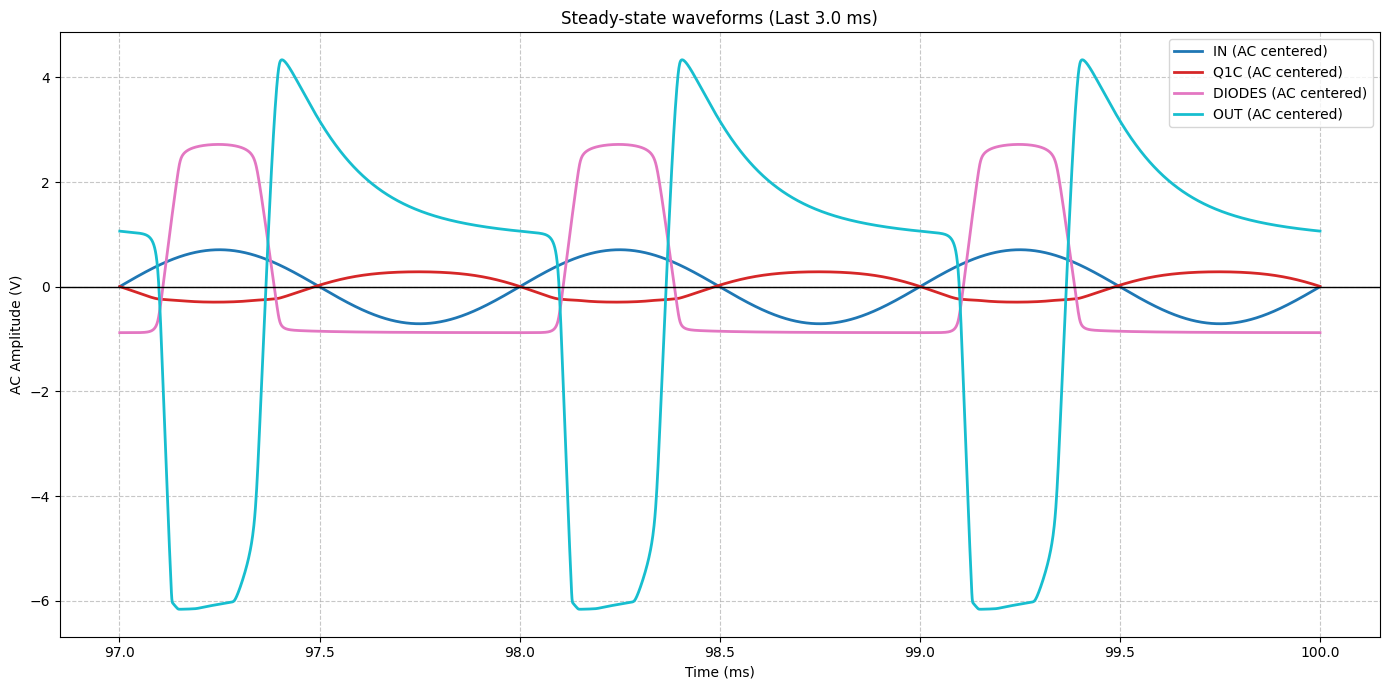

In [72]:
import os
os.system("cp preamp.net preamp-backup.net")
import os
import shutil
import logging
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal.windows import flattop
from spicelib import SpiceEditor, SimRunner, RawRead
from spicelib.simulators.ltspice_simulator import LTspice

# ==========================================
# 1. LOGGING CONFIGURATION
# ==========================================
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)-8s | %(message)s',
    datefmt='%H:%M:%S'
)
logger = logging.getLogger(__name__)

class MacLTspice(LTspice):
    spice_exe = ['/Applications/LTspice.app/Contents/MacOS/LTspice']

def adjust_component_values(netlist):
    """
    Safely modifies component values without dropping hidden lines.
    """
    new_lines = []
    for raw_line in netlist.netlist:
        # Split any hidden carriage returns to prevent deleting grouped components
        sub_lines = raw_line.replace('\r', '\n').split('\n')
        
        for line in sub_lines:
            if not line.strip():
                continue
                
            # Strip whitespace to ensure startswith() matches correctly
            upper_line = line.strip().upper()
            
            # 1. Re-bias Stage 2 for massive symmetrical headroom
            if upper_line.startswith('R5 '):
                new_lines.append('R5 N003 0 10K\n')
            # 1b. Max Gain "Crank" - Push for high saturation
            elif upper_line.startswith('R24 '):
                new_lines.append('R24 N012 Q1E 47\n') # Dropped to 47 ohms for maximum diode drive
            elif upper_line.startswith('R8 '):
                new_lines.append('R8 Q1E 0 1K\n')
            elif upper_line.startswith('R7 '):
                new_lines.append('R7 Q2C Q1E 15k\n')
            elif upper_line.startswith('.PARAM P4'):
                new_lines.append('.param P4 = 1\n')
            # 2. Adjust Makeup Gain for the 1.3V target (Balanced for lower THD)
            elif upper_line.startswith('R22 '):
                new_lines.append('R22 Q4E N014 120\n') 
                
            # 3. Attenuate Input (Balanced to share the gain load)
            elif upper_line.startswith('C_OUT '):
                new_lines.append('C_out N_DIV J1S 100n\n')
                new_lines.append('R_atten N_DIV Q1B 470k\n') # Lowered to 470k for the final 13% voltage boost
            else:
                # Add \n if it doesn't have one, based on your previous fix
                if not line.endswith('\n'):
                    new_lines.append(line + '\n')
                else:
                    new_lines.append(line)
                
    netlist.netlist = new_lines
    
# ==========================================
# 2. MAIN CLASS
# ==========================================
class PreampAnalyzer:
    def __init__(self, netlist_template, output_dir):
        self.netlist_template = netlist_template
        self.output_dir = output_dir
        self.freq_hz = 1000.0  # Fundamental frequency
        
        self.raw_path = None
        self.sim_file = None

    def prepare_workspace(self):
        """Cleans and recreates the results directory."""
        logger.info(f"Cleaning working directory: {self.output_dir}")
        if os.path.exists(self.output_dir):
            shutil.rmtree(self.output_dir)
        os.makedirs(self.output_dir)

    def prepare_netlist(self, output_filename, input_amp=1.0):
            """Cleans the netlist, fixes formatting bugs, and configures the transient analysis."""
            logger.info("Preparing Netlist for steady-state analysis...")
            netlist = SpiceEditor(self.netlist_template)
    
            # 1. Remove previous components and commands
            components_to_delete = ['V1', 'B1', 'B2', 'V_AC']
            for comp in components_to_delete:
                try: netlist.remove_component(comp)
                except: pass
    
            commands_to_delete = ['.ac', '.wave', '.step', '.tran']
            for line in list(netlist.netlist):
                if any(line.lower().startswith(cmd) for cmd in commands_to_delete):
                    netlist.netlist.remove(line)
    
            # 2. BUG FIX: Remove orphaned blank lines before proceeding
            netlist.netlist = [x for x in netlist.netlist if x.strip()]
    
            # 3. Inject new signal and configuration
            netlist.add_instruction(f"V_IN IN 0 SINE(0 {input_amp} 1k)")
            netlist.add_instruction(".options plotwinsize=0") 
            netlist.add_instruction(".tran 0 1.1 1.0 1u")
    
            # Freeze potentiometers
            netlist.set_parameters(vol=1.0, drive=0.0, bass=0.5, treble=0.5)
    
            # ----------------------------------------------------
            # APPLY OUR COMPONENT ADJUSTMENTS HERE
            # ----------------------------------------------------
            adjust_component_values(netlist)
    
            # 4. Final cleanup and save
            netlist.netlist = [x for x in netlist.netlist if x.strip()]
            self.sim_file = os.path.join(self.output_dir, output_filename)
            netlist.save_netlist(self.sim_file)
            logger.info(f"Netlist successfully saved to {self.sim_file}")

    def run_simulation(self):
        """Runs LTspice."""
        logger.info("Launching LTspice simulation...")
        runner = SimRunner(simulator=MacLTspice, output_folder=self.output_dir)
        runner.run(self.sim_file)
        
        for raw, _ in runner:
            self.raw_path = raw
        logger.info("Simulation finished.")

    # ==========================================
    # 3. CALCULATION METHODS
    # ==========================================
    def _get_dc_and_peaks(self, voltage):
        dc_bias = np.mean(voltage)
        v_max = np.max(voltage)
        v_min = np.min(voltage)
        return dc_bias, v_max, v_min

    def _calculate_thd(self, time, voltage, dc_bias):
            num_samples = len(time)
            time_uniform = np.linspace(time[0], time[-1], num_samples)
            voltage_uniform = interp1d(time, voltage, kind='linear')(time_uniform)
            
            voltage_ac = voltage_uniform - dc_bias
            
            # Using Flat-top window for more accurate amplitude measurements
            window = flattop(num_samples)
            fft_result = np.fft.rfft(voltage_ac * window)
            fft_mag = np.abs(fft_result) * 2 / np.sum(window)
            
            dt = time_uniform[1] - time_uniform[0]
            freqs = np.fft.rfftfreq(num_samples, d=dt)
    
            harmonics = []
            search_width = 5  # Local peak search
            
            for i in range(1, 11):
                target_f = self.freq_hz * i
                idx_center = np.argmin(np.abs(freqs - target_f))
                
                idx_start = max(0, idx_center - search_width)
                idx_end = min(len(fft_mag), idx_center + search_width + 1)
                
                peak_mag = np.max(fft_mag[idx_start:idx_end])
                harmonics.append(peak_mag)
    
            v_fund = harmonics[0]
            
            if v_fund <= 1e-6:
                return 0.0, 0.0
                
            # Total harmonic distortion (Sum of 2nd through 10th)
            v_harmonics_sq = sum(h**2 for h in harmonics[1:])
            
            # Even harmonic distortion (2nd, 4th, 6th, 8th, 10th)
            # These are at indices 1, 3, 5, 7, 9 in our 0-indexed list
            v_even_sq = sum(harmonics[i]**2 for i in range(1, 10, 2))
            
            thd_total = (np.sqrt(v_harmonics_sq) / v_fund) * 100.0
            thd_even = (np.sqrt(v_even_sq) / v_fund) * 100.0
            
            return thd_total, thd_even

    # ==========================================
    # 4. REPORTS AND CHARTS
    # ==========================================
    def analyze_nodes(self, nodes):
            if not self.raw_path or not os.path.exists(self.raw_path):
                logger.error("RAW file not found.")
                return
    
            raw = RawRead(self.raw_path)
            time = raw.get_trace('time').get_wave(0)
            available_traces = [t.lower() for t in raw.get_trace_names()]
            
            # Added EVEN THD to the header and expanded the border length
            header = f"{'NODE':<12} | {'DC BIAS':<9} | {'V MIN':<9} | {'V MAX':<9} | {'HEADROOM TOP':<12} | {'HEADROOM BOT':<12} | {'THD (%)':<8} | {'EVEN THD':<8}"
            print("\n" + "="*97)
            print(header)
            print("-" * 97)
    
            for node in nodes:
                trace_name = f'V({node})'
                if trace_name.lower() in available_traces:
                    exact_name = next(t for t in raw.get_trace_names() if t.lower() == trace_name.lower())
                    voltage = np.real(raw.get_trace(exact_name).get_wave(0))
                    
                    dc_bias, v_max, v_min = self._get_dc_and_peaks(voltage)
                    swing_top = v_max - dc_bias
                    swing_bot = dc_bias - v_min
                    
                    # Unpack both THD values
                    thd_total, thd_even = self._calculate_thd(time, voltage, dc_bias)
                    
                    print(f"{node:<12} | {dc_bias:>7.3f} V | {v_min:>7.3f} V | {v_max:>7.3f} V | {swing_top:>10.3f} V | {swing_bot:>10.3f} V | {thd_total:>7.2f}% | {thd_even:>7.2f}%")
                else:
                    logger.warning(f"Node {node} not found.")
            print("=" * 97 + "\n")

    def plot_key_waveforms(self, nodes_to_plot, window_ms=3.0):
        """Plots the last 'window_ms' milliseconds of the sinusoids."""
        if not self.raw_path or not os.path.exists(self.raw_path):
            return

        logger.info("Generating waveform plot...")
        raw = RawRead(self.raw_path)
        time = raw.get_trace('time').get_wave(0)
        
        # Isolate the last milliseconds to see 3 clear cycles
        time_limit = time[-1] - (window_ms / 1000.0)
        mask = time >= time_limit
        time_plot = time[mask] * 1000.0  # Convert to ms

        plt.figure(figsize=(14, 7))
        available_traces = [t.lower() for t in raw.get_trace_names()]
        
        # Consistent colors
        colors = plt.cm.tab10(np.linspace(0, 1, len(nodes_to_plot)))

        for idx, node in enumerate(nodes_to_plot):
            trace_name = f'V({node})'
            if trace_name.lower() in available_traces:
                exact_name = next(t for t in raw.get_trace_names() if t.lower() == trace_name.lower())
                voltage = np.real(raw.get_trace(exact_name).get_wave(0))
                
                # To compare them visually, we remove the DC Bias (optional)
                # If you want to see them at their true DC level, comment out the following line:
                voltage_ac = voltage[mask] - np.mean(voltage) 
                
                plt.plot(time_plot, voltage_ac, label=f'{node} (AC centered)', color=colors[idx], linewidth=2)

        plt.title(f"Steady-state waveforms (Last {window_ms} ms)")
        plt.xlabel("Time (ms)")
        plt.ylabel("AC Amplitude (V)")
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.axhline(0, color='black', linewidth=1)
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.show()

# ==========================================
# ENTRY POINT (MAIN)
# ==========================================
if __name__ == "__main__":
    # Expanded nodes based on your schematic (All explicitly named nodes)
    COMPLETE_NODES = [
        # --- Input and First Stage ---
        'IN',           # Original input signal
        'Q1B',          # Q1 Base
        'Q1E',          # Q1 Emitter
        'Q1C',          # Q1 Collector
        'Q2C',          # Q2 Collector (Part of the gain stage)
        
        # --- Clipping Stage ---
        'MID_IN',       # Input to the diode stage
        'DIODES',       # Main clipping node
        
        # --- JFET and Tone Stack ---
        'J1S',          # J1 JFET Source
        'AFTER_TONE',   # Tone stack output / input to Make-up gain
        
        # --- Make-up Gain ---
        'Q4B',          # Q4 Base
        'Q4E',          # Q4 Emitter
        'Q4C',          # Q4 Collector
        
        # --- Output Buffer ---
        'Q3B',          # Q3 Base
        'Q3E',          # Q3 Emitter
        'Q3C',          # Q3 Collector (Also acts as local voltage rail/VCC)
        
        # --- Filtering/Power Nodes ---
        'C5',           # Filter capacitor node C5
        'C6',           # Filter capacitor node C6
        
        # --- Output ---
        'OUT'           # Final output
    ]
    
    # Nodes selected for the plot (plotting all 11 would be visual chaos)
    PLOT_NODES = ['IN', 'Q1C', 'DIODES', 'OUT']

    # Note: Updated output_dir to English 'tran_results' as well.
    analyzer = PreampAnalyzer(netlist_template="preamp-backup.net", output_dir='./tran_results')
    analyzer.prepare_workspace()
    
    analyzer.prepare_netlist("preamp_tran.net", input_amp=0.707)
    analyzer.run_simulation()
    
    # 1. Show detailed table
    analyzer.analyze_nodes(nodes=COMPLETE_NODES)
    import time
    time.sleep(1)
    # 2. Show signal overlay
    analyzer.plot_key_waveforms(nodes_to_plot=PLOT_NODES, window_ms=3.0)